# 02 LSTM Models With True Sequences Using Sliding Windows and Even Smaller Validation and Test Sizes
This notebook continues using the true (i.e., "correct") sequences as described previously, but it experiments with even smaller validation and test sizes, as well as the use of sliding windows. The thought behind the former was to simulate a real-world situation, where we would theoretically have ALL the past data, and we would only need to predict the current day's close. Therefore, extending our training data to every single day before the final validation and test days should not be a problem.

The idea behind the sliding windows is similarly to simulate what might happen in the real-world. Specifically, instead of training on every single piece of training data that we have, we can train on a sub-set of it, and then get one day of validation and test accuracies (for each ticker). For example, we might train on the first 98 days of data, then use the 99th day for validation, and then the 100th day for test. Afterwards, we would "slide" this window over by one day, using days 2-99 for training, day 100 for validation, and day 101 for test. We would then continue doing this until we reach the end of our dataset. This would ultimately give us the most recent data for training, and we can obtain appropriate test accuracies by testing for each day independently.

The main subject of discussion is whether or not we re-train the model from scratch for every window, or somehow integrate previous model parameters each time we slide the window over. Below, we describe some pros and cons to both, but ultimately, we did not perform this task as 1) it would take too long and we only have so much time for this project, and 2) we found that we sacrificed accuracy because we have less training data for each "slide." We did try to mitigate the latter problem by extending the time period for all the windows, but we ultimately concluded these experiments here.

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model
This is the same as the previous two notebooks

## Getting S&P500 Table Data

### Old method (risky since S&P500 Wikipedia might change randomly)

As of March 11, 2025, the last time a stock was added or removed from the S&P500 Wikipedia list was in December 2024. Therefore, for the extent of this project thus far, this shouldn't have affected us at all. However, we should keep a consistent csv of the stocks so we can have consistent GICS sectors (in case they change for some reason).

In [27]:
# Getting the S&P500 tables
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')

In [26]:
# Getting the S&P500 list into a csv (only need to do once)
# df_sp500 = sp500_tables[0]
# df_sp500.to_csv('SP500_Tickers_March_2025.csv')

### Get S&P500 current list of stocks and their sectors using downloaded csv file

In [2]:
sp500_tables = pd.read_csv('SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [3]:
# Loading in stock data
data = pd.read_csv("SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [4]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [5]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Outcome variables - Close price minus the Open price and variations of that

In [6]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [7]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [8]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [9]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [11]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features
**This is where we** ***correctly*** **scale our features for proper time-series LSTM modeling.**

As we will explain in more detail in throughout this section, we normalize to the maximum of each ticker (instead of to each current day's Open like we did in previous notebooks) in order to preserve long-term price changes. In essence, this means that for most of the days for every ticker, the values will be between 0 and some maximum, with only a few of the days ever reaching that maximum. We decide to have our normalized maximum be equal to 2, so any values that are scaled using this process will range from 2 down to 0 (if there are any that go that low). We choose 2 because we want the mean of these scaled features to be ~1, which matches nicely with the mean of the other features not scaled this way (e.g., NATR or RSI). This will hopefully help the training, as we want our learning rate to affect all the features with roughly the same magnitude.

We also double-check that the percent differences between features (e.g., percent difference between the Previous Day Low and the Previous Day Close) remain the same for each day across all the tickers after scaling, as we want to keep these proportional differences in the data. One example could be the following: if the previous OHLC prices for a day were 100, 120, 60, and 80, they may be scaled down to 0.5, 0.6, 0.3, and 0.4, with their relative percent differences remaining intact. Notice as well that none of these values reach 2, which means the global maximum price for this ticker within this time period is not on this particular day.

In [12]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [13]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [14]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [15]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [16]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [17]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [18]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [19]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [23]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

# LSTM Model Testing with Sliding Windows and Smaller Val/Test Sizes
"Smaller" meaning anything from 5 to 1 test and validation observations

## Creating dummy variables for GICS Sector

In [25]:
# Getting a copy of data_small called data_smallest
data_smallest = data_small.copy()

In [26]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smallest['GICS Sector'],
    drop_first = False
)
print("Number of data_smallest dummy variables:", data_smallest['GICS Sector'].nunique())
print("Shape of data_smallest dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smallest
data_smallest = pd.concat(
    [data_smallest, sector_dummy],
    axis=1
)

Number of data_smallest dummy variables: 12
Shape of data_smallest dummy variable for GICS Sector: (453625, 12) 



In [27]:
# Checking to make sure dummies were created correctly
data_smallest.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [28]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smallest = data_smallest.drop("GICS Sector", axis = 1)

print("Shape of data_smallest after removing original GICS Sector feature:",
      data_smallest.shape)

Shape of data_smallest after removing original GICS Sector feature: (453625, 36)


## Function for Creating Sequences for LSTM Model
Again, this is the same function as before

In [29]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)
    
    return X, Y

## LSTM Classification (all stocks, longer series, test and val sizes of 1 day per ticker, simpler model)

### Generating X continuous series sequences, Y continuous labels, and splitting data into train, val, test sets

In [31]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smallest, Y_data_smallest = create_sequences_grouped(data_smallest, seq_length, group_col, target_col, drop_cols)

In [33]:
# Confirming shapes
print('Shape of X_data_smallest:', X_data_smallest.shape)
print('Shape of Y_data_smallest:', Y_data_smallest.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smallest
unique_tickers = data_smallest['Ticker'].nunique()
unique_dates = data_smallest['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smallest:', unique_tickers)
print('Number of unique dates in data_smallest:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1, '\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smallest.shape[0])

Shape of X_data_smallest: (437475, 35, 32)
Shape of Y_data_smallest: (437475,) 

Number of unique tickers in data_smallest: 475
Number of unique dates in data_smallest: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921 

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [50]:
# Splitting the data into train, validation, and test sets
X_train = X_data_smallest[:-(unique_tickers*2)]  # Up to penultimate day for each ticker
Y_train = Y_data_smallest[:-(unique_tickers*2)]  # Up to penultimate day for each ticker
X_val = X_data_smallest[-(unique_tickers*2):-unique_tickers]  # Penultimate day of each ticker
Y_val = Y_data_smallest[-(unique_tickers*2):-unique_tickers]  # Penultimate day of each ticker
X_test = X_data_smallest[-unique_tickers:]  # Last day of each ticker
Y_test = Y_data_smallest[-unique_tickers:]  # Last day of each ticker

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_val:', X_val.shape)
print('Shape of Y_val:', Y_val.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', X_train.shape[0] / unique_tickers)
print('Number of dates in X_val:', X_val.shape[0] / unique_tickers)
print('Number of dates in X_test:', X_test.shape[0] / unique_tickers)

Shape of X_train: (436525, 35, 32)
Shape of Y_train: (436525,)
Shape of X_val: (475, 35, 32)
Shape of Y_val: (475,)
Shape of X_test: (475, 35, 32)
Shape of Y_test: (475,) 

Number of dates in X_train: 919.0
Number of dates in X_val: 1.0
Number of dates in X_test: 1.0


### Building and compiling simpler LSTM model

In [32]:
# Defining a function to create and compile tf model only one LSTM layer (also 256 units and dropout of 0.3)
def build_LSTM_model_simple(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=256, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [52]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_simple = build_LSTM_model_simple(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 256)            │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,707 (1.13 MB)

 Trainable params: 296,707 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [53]:
# Training the model using the training dataset
model_LSTM_simple_fit = model_LSTM_simple.fit(
    x = X_train,
    y = Y_train,
    validation_data = [X_val, Y_val],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 154s 90ms/step - accuracy: 0.3967 - loss: 1.0770 - val_accuracy: 0.3811 - val_loss: 1.0877
Epoch 2/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 151s 88ms/step - accuracy: 0.4225 - loss: 1.0625 - val_accuracy: 0.4042 - val_loss: 1.0814
Epoch 3/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 153s 90ms/step - accuracy: 0.4337 - loss: 1.0562 - val_accuracy: 0.4063 - val_loss: 1.0669
Epoch 4/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 161s 94ms/step - accuracy: 0.4517 - loss: 1.0405 - val_accuracy: 0.4968 - val_loss: 1.0000
Epoch 5/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 156s 91ms/step - accuracy: 0.4747 - loss: 1.0151 - val_accuracy: 0.5011 - val_loss: 0.9761
Epoch 6/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 161s 94ms/step - accuracy: 0.4925 - loss: 0.9909 - val_accuracy: 0.5305 - val_loss: 0.9570
Epoch 7/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 164s 96ms/step - accuracy: 0.5080 - loss: 0.9715 - val_accuracy: 0.5495 - val_loss: 0.9530
Epoch 8/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 166s 97ms/step - accuracy: 

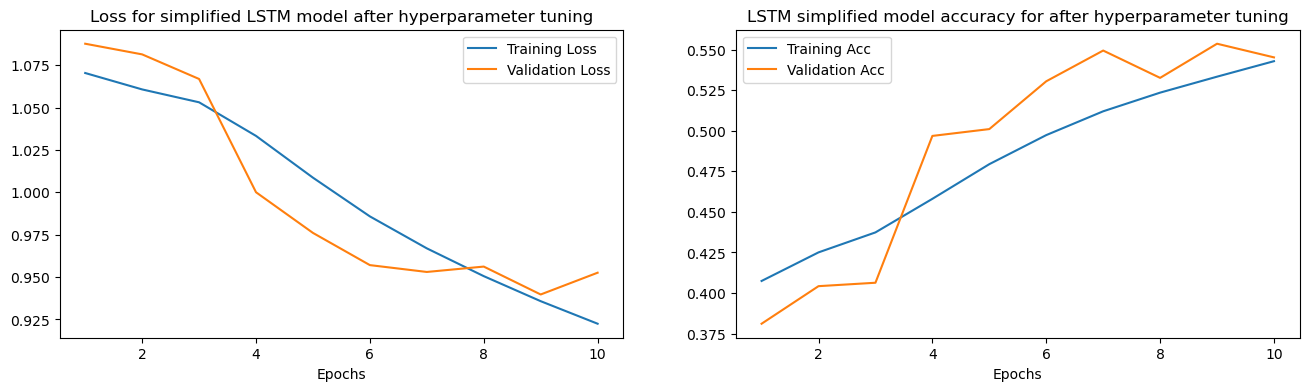

In [55]:
# Plotting the loss on the first subplot
hist_s = model_LSTM_simple_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simplified LSTM model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simplified model accuracy for after hyperparameter tuning')
plt.show()

In [56]:
print("Final training accuracy:", hist_s['accuracy'][-1])
print("Final validation accuracy:", hist_s['val_accuracy'][-1])

Final training accuracy: 0.5429196357727051
Final validation accuracy: 0.5452631711959839


It took about 2.5 minutes to run each epoch, and the model seems to be performing pretty decently with this more recent data. What's interesting is the huge jump in accuracy from epochs 3-4, though this might just be due to variance. Another possibility for variance is simply the validation accuracy itself, as there are only 475 pieces of data to recognize. Training the model using different weights, or even with a different OS, might result in significantly different results. As it stands, however, we get solid training and validation accuracies, and we'll see how it compares to the test accuracy.

In [59]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple.evaluate(X_test, Y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4523 - loss: 1.0874


[1.0746856927871704, 0.4273684322834015]

Somewhat surprisingly, the test accuracy was significantly worse compared to the training and validation accuracies. This, again, might be due to the small number of samples in our test data (475), but this result is definitely somewhat surprising. To ensure that this is just variance, we can try running the model again, perhaps with a different seed. However, what might be more valuable is to move on to the next step of running the model in sequence for each day, only using perhaps 100 days of training examples each time (instead of all ~900 at once). This encompasses our desire to test if the test accuracy we got here was simply due to variance, as we will be able to see how our model does with the test data for multiple days in a row.

## LSTM Classification (everything above, sliding 98/1/1 window)
This will be a continuation of the previous experiment, but instead of training with all the data in one go and predicting the validation and test data at the end, we will only use 100 days of data for our train/val/test split, and then continuously shift the data one day over for all the days in our data. This more closely simulates what might happen in the real-world, where we get more data every single day, and we would need to use that data to re-calibrate our model.

In terms of the weights, we can either 1) re-train the model every time starting with new weights, or 2) find a way to train using the first 100 days of data, and then re-train the model using the pre-established weights after we shift our window over by 1 for the next day. The former might be a bit easier to implement, and it might reduce some noise in our model from previous days, while the latter might be able to use the information from those previous days to better predict future prices. It might be worthwhile to test both.

### Generating X continuous series sequences and Y continuous labels

In [60]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smallest, Y_data_smallest = create_sequences_grouped(data_smallest, seq_length, group_col, target_col, drop_cols)

In [64]:
# Confirming shapes
print('Shape of X_data_smallest:', X_data_smallest.shape)
print('Shape of Y_data_smallest:', Y_data_smallest.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smallest
unique_tickers = data_smallest['Ticker'].nunique()
unique_dates = data_smallest['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smallest:', unique_tickers)
print('Number of unique dates in data_smallest:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1, '\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smallest.shape[0])

Shape of X_data_smallest: (437475, 35, 32)
Shape of Y_data_smallest: (437475,) 

Number of unique tickers in data_smallest: 475
Number of unique dates in data_smallest: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921 

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


### Defining function for splitting sequence data into train, val, and test splits

In [121]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

### Defining function for building and compiling LSTM model for sliding train/val/test windows

In [134]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=128, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Running the LSTM model with sliding train, val, and test sets (weights starting from scratch)

In [136]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
n_classes = 3
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

In [137]:
# Defining variables and for loop to run through rolling windows
num_sequences_per_ticker = unique_dates - seq_length + 1
window_size = 100

# for start_day_num in range(num_sequences_per_ticker - window_size + 1):
for start_day_num in range(200, 201):
    # Getting the windows for X and Y
    X_window = X_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]
    Y_window = Y_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]

    # Splitting data into train, val, and test sets
    X_train, Y_train, X_val, Y_val, X_test, Y_test = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, 98, 1, 1)

    # Finishing setting hyperparameters
    seq_length = X_train.shape[1]
    num_features = X_train.shape[2]

    # Building the model
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                              num_features=num_features,
                                              n_classes=n_classes,
                                              learning_rate=learning_rate,
                                              activation=activation,
                                              optimizer=optimizer,
                                              metric=metric)

    # Fitting the model
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train,
        y = Y_train,
        validation_data = [X_val, Y_val],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)

    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    print("Final training accuracy:", hist_sl['accuracy'][-1])
    print("Final validation accuracy:", hist_sl['val_accuracy'][-1])
    
    # Evaluating the model
    evaluated_model = model_LSTM_slide.evaluate(X_test, Y_test)
    print("Final test accuracy:", evaluated_model[1])
    

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.3564 - loss: 1.1082 - val_accuracy: 0.3789 - val_loss: 1.0893
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.3853 - loss: 1.0820 - val_accuracy: 0.3789 - val_loss: 1.0859
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.3927 - loss: 1.0799 - val_accuracy: 0.3684 - val_loss: 1.0861
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.3947 - loss: 1.0785 - val_accuracy: 0.3811 - val_loss: 1.0855
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.4003 - loss: 1.0761 - val_accuracy: 0.3705 - val_loss: 1.0853
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.4016 - loss: 1.0753 - val_accuracy: 0.3895 - val_loss: 1.0853
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.4056 - loss: 1.0735 - val_accuracy: 0.3853 - val_loss: 1.0851
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.4070 - loss: 1.0731 - val_accuracy: 0.

Overall, because the accuracies do not seem great (though we did get lucky with this particular test accuracy), it appears that we might need more data in our rolling window to make this work. We choose not to run the model with the 100-day sliding windows, because 1) the results simply do not look very promising (likely because 100 days is not enough) and 2) it will take far too long to run. We will try a 500-day or 700-day window instead, each moving every 5 days instead of 1 day. This will hopefully increase the accuracy of the model, along with making it run faster.

## LSTM Classification (everything originally, sliding 690/5/5 window)
This will be another continuation of the previous experiment, but instead of the 98/1/1 train/val/test window and sliding every day, we will use a 690/5/5 window to 1) get more training data, and 2) make the process run faster. 100 days of training data definitely didn't seem to be enough, and unless we simplified the model greatly, it took quite awhile to run. Using this more robust shifting dataset will hopefully make our model run better, and we can hopefully implement the entire rolling simulation (instead of just testing on 1 particular time frame as we did previously).

*Note: we did try a 490/5/5 sliding window as well, but it did not perform as well, so we scrapped it.

### Generating X continuous series sequences and Y continuous labels
Same as before

In [182]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smallest, Y_data_smallest = create_sequences_grouped(data_smallest, seq_length, group_col, target_col, drop_cols)

In [183]:
# Confirming shapes
print('Shape of X_data_smallest:', X_data_smallest.shape)
print('Shape of Y_data_smallest:', Y_data_smallest.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smallest
unique_tickers = data_smallest['Ticker'].nunique()
unique_dates = data_smallest['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smallest:', unique_tickers)
print('Number of unique dates in data_smallest:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1, '\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smallest.shape[0])

Shape of X_data_smallest: (437475, 35, 32)
Shape of Y_data_smallest: (437475,) 

Number of unique tickers in data_smallest: 475
Number of unique dates in data_smallest: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921 

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


### Defining function for splitting sequence data into train, val, and test splits
Same as before

In [184]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

### Defining function for building and compiling LSTM model for sliding train/val/test windows
Changed back to 256 units like we had originally

In [185]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=256, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Running the LSTM model with sliding train, val, and test sets (weights starting from scratch)

In [186]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
n_classes = 3
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256  # Changed back to 256

#### Testing with two days (arbitrarily with one starting from day 200 and the other from day 205)

In [199]:
# Defining variables and for loop to run through rolling windows
num_sequences_per_ticker = unique_dates - seq_length + 1
window_size = 700
slide_amount = 5
train_window = 690
val_window = 3
test_window = 7
test_accuracies_total = {}

# for start_day_num in range(0, num_sequences_per_ticker - window_size + 1, slide_amount):
for start_day_num in range(200, 206, 5):
    # Getting the windows for X and Y
    X_window = X_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]
    Y_window = Y_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]

    # Splitting data into train, val, and test sets
    X_train, Y_train, X_val, Y_val, X_test, Y_test = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window, val_window, test_window)

    # Finishing setting hyperparameters
    seq_length = X_train.shape[1]
    num_features = X_train.shape[2]

    # Building the model
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                              num_features=num_features,
                                              n_classes=n_classes,
                                              learning_rate=learning_rate,
                                              activation=activation,
                                              optimizer=optimizer,
                                              metric=metric)

    # Fitting the model
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train,
        y = Y_train,
        validation_data = [X_val, Y_val],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)

    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    print("Final training accuracy:", hist_sl['accuracy'][-1])
    print("Final validation accuracy:", hist_sl['val_accuracy'][-1])
    
    # Evaluating the model
    test_accuracies_by_day = []  # Initializing test accuracies for each day
    for day in range(int(X_test.shape[0] / unique_tickers)):
    
        # Getting one day of test accuracies
        X_test_one_day = X_test[(day * unique_tickers):((day+1) * unique_tickers)]
        Y_test_one_day = Y_test[(day * unique_tickers):((day+1) * unique_tickers)]
    
        # Evaluating test accuracies of all tickers for that day and appending to list
        evaluated_model = model_LSTM_slide.evaluate(X_test_one_day, Y_test_one_day)
        test_accuracies_by_day.append(evaluated_model[1])

    # Putting the test accuracy list into the overall test accuracy dictionary
    test_accuracies_total[start_day_num] = test_accuracies_by_day

Epoch 1/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 120s 94ms/step - accuracy: 0.3936 - loss: 1.0792 - val_accuracy: 0.3782 - val_loss: 1.0904
Epoch 2/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 118s 92ms/step - accuracy: 0.4198 - loss: 1.0642 - val_accuracy: 0.3867 - val_loss: 1.0906
Epoch 3/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 119s 93ms/step - accuracy: 0.4292 - loss: 1.0593 - val_accuracy: 0.3965 - val_loss: 1.0882
Epoch 4/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 114s 89ms/step - accuracy: 0.4370 - loss: 1.0537 - val_accuracy: 0.4330 - val_loss: 1.0710
Epoch 5/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 119s 93ms/step - accuracy: 0.4518 - loss: 1.0399 - val_accuracy: 0.4400 - val_loss: 1.0538
Epoch 6/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 120s 93ms/step - accuracy: 0.4695 - loss: 1.0205 - val_accuracy: 0.4604 - val_loss: 1.0398
Epoch 7/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 117s 92ms/step - accuracy: 0.4838 - loss: 1.0022 - val_accuracy: 0.4688 - val_loss: 1.0292
Epoch 8/10
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 115s 90ms/step - accuracy: 

In [203]:
# Average of the test accuracies for the first sets of days:
test_accuracy_200 = np.average(test_accuracies_total[200])
test_accuracy_205 = np.average(test_accuracies_total[205])

print("Test accuracy for the first set of days:", test_accuracy_200)
print("Test accuracy for the second set of days:", test_accuracy_205)

Test accuracy for the first set of days: 0.46736841968127657
Test accuracy for the second set of days: 0.49864662119320463


Even from just these two randomly chosen starting days, we see that there seems to be a lot of variation in the accuracies. From the first round of training, we achieved a validation accuracy of ~49%, with an average test accuracy across the next 7 days of ~47%. From the second round of training - recall that we reset the model each round - we achieved a validation accuracy of ~45%, with an average test accuracy across the next 7 days of ~50%. This variation in accuracies seems arbitrary, and we hypothesize that it's simply due to the variance in these particular trading days (and that there are only 3 validation days and 7 test days).

Importantly, we also notice (at least from these tests) that 1) the validation accuracies aren't too different from the test accuracies, and 2) the test accuracies day by day doesn't seem to be decreasing. In theory, forecast models with the most recent data should perform better than models with older data, but that doesn't seem to matter much here. It might be worthwhile to extend the test dataset and see if test accuracy day-by-day declines over a longer period of time.

In [216]:
# Evaluating the test accuracy for the remaining data (continuing from the previous experiment)
prev_test_window_start = 205 - test_window
X_test_remaining = X_data_smallest[(unique_tickers * (prev_test_window_start + window_size)):]  # Getting the remaining dates to test
Y_test_remaining = Y_data_smallest[(unique_tickers * (prev_test_window_start + window_size)):]  # Getting the remaining labels

test_accuracies_remaining = []
for day in range(int(X_test_remaining.shape[0] / unique_tickers)):

    # Getting one day of test accuracies
    X_test_one_day_r = X_test_remaining[(day * unique_tickers):((day+1) * unique_tickers)]
    Y_test_one_day_r = Y_test_remaining[(day * unique_tickers):((day+1) * unique_tickers)]

    # Evaluating test accuracies of all tickers for that day and appending to list
    evaluated_model_r = model_LSTM_slide.evaluate(X_test_one_day_r, Y_test_one_day_r)
    test_accuracies_remaining.append(evaluated_model_r[1])

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5818 - loss: 0.8685
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4089 - loss: 1.0769
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6208 - loss: 0.8416
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4456 - loss: 1.0547
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4480 - loss: 0.9890
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4994 - loss: 0.9990
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5242 - loss: 0.9252
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4514 - loss: 1.0620
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5261 - loss: 0.9897
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4586 - loss: 1.0440
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5745 - loss: 0.9233
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4809 - loss: 1.0041
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5915 - loss: 0.8073
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/ste

The first 7 results match what we had previously, so we can be confident that this process worked. We can also get a line graph to see what the accuracies actually look like:

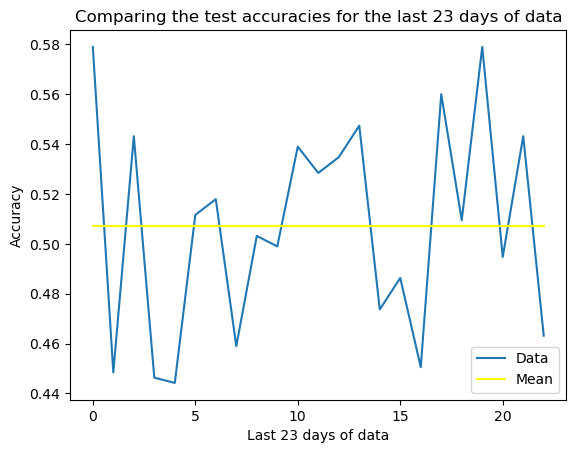

In [255]:
# Getting the mean accuracy
data_mean = np.array(test_accuracies_remaining).mean()
mean_values = np.ones(len(test_accuracies_remaining)) * data_mean
days = np.arange(len(test_accuracies_remaining))

# Getting a line graph of the last 23 test accuracies:
plt.plot(test_accuracies_remaining, label='Data')
plt.plot(days, mean_values, label='Mean', color='yellow')
plt.xlabel('Last 23 days of data')
plt.ylabel('Accuracy')
plt.title('Comparing the test accuracies for the last 23 days of data')
plt.legend()
plt.show()

We once again see a pretty random combination of test accuracies. It moves around quite arbitrarily, and depending on the day, it can be as low as 44% or as high as 58%. We of course need to be cautious because we have so little test days to go off of, but it does seem like the continuous time series aspect of our model doesn't matter as much. More specifically, while there does appear to be patterns in the sequence data, it does not appear to rely on what happened in the most recent days.

In other words, assuming we trained this model on 1000 days of data and we wanted to predict the outcome of both the 1001st day and the 1050th day, we wouldn't expect our accuracies to be any higher or lower between them. This doesn't seem to make sense initially, as know internally that past days (especially the most recent past days) have an effect on future days. However, at least with this dataset and model, it seems that we can rely on the patterns themselves, and that can extrapolated to whatever day we want to test this on. Speaking of which, we can actually try evaluating our model for the first 200 days, as we have not seen them whatsoever:

In [231]:
# Evaluating the test accuracy for the first 200 days of data
X_test_first_200 = X_data_smallest[:(unique_tickers * 200)]  # Getting the first 200 days of data to test
Y_test_first_200 = Y_data_smallest[:(unique_tickers * 200)]  # Getting the first 200 days of labels

test_accuracies_first_200 = []
for day in range(int(X_test_first_200.shape[0] / unique_tickers)):

    # Getting one day of test accuracies
    X_test_one_day_f_200 = X_test_first_200[(day * unique_tickers):((day+1) * unique_tickers)]
    Y_test_one_day_f_200 = Y_test_first_200[(day * unique_tickers):((day+1) * unique_tickers)]

    # Evaluating test accuracies of all tickers for that day and appending to list
    evaluated_model_first_200 = model_LSTM_slide.evaluate(X_test_one_day_f_200, Y_test_one_day_f_200, verbose=0)
    test_accuracies_first_200.append(evaluated_model_first_200[1])

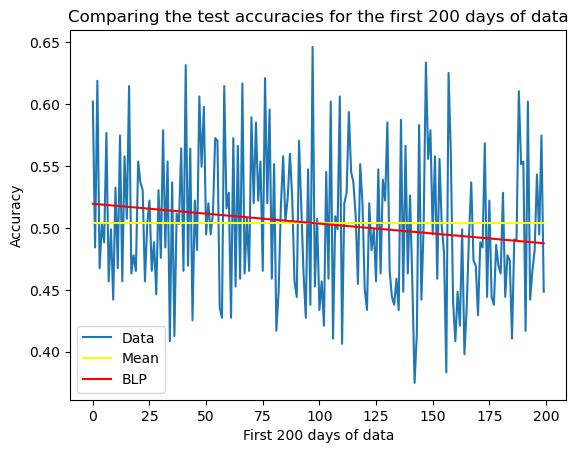

In [249]:
# Getting a regression line and mean
y = np.array(test_accuracies_first_200)  # Sample x data
x = np.arange(x.shape[0])  # Sample y data
m, b = np.polyfit(x, y, 1)  # m = slope, b = intercept
data_mean = y.mean()
mean_values = np.ones(x.shape[0]) * data_mean

# Getting a line graph of the first 200 test accuracies:
plt.plot(y, label='Data')
plt.plot(x, mean_values, label='Mean', color='yellow')
plt.plot(x, m*x + b, color='red', label='BLP')
plt.xlabel('First 200 days of data')
plt.ylabel('Accuracy')
plt.title('Comparing the test accuracies for the first 200 days of data')
plt.legend()
plt.show()

As we can see here, we do see a general trend of the accuracy going down, but that doesn't matter as much since we're using future data to predict what would've happened anyway; basically, this is more likely just due to variance. What's interesting is that the test accuracies is still higher than a 50% average, which means we are indeed doing quite well. What we can test next is to get the confusion matrix numbers to truly see how well our model did.

#### Full test (with confusion matrix variables as well) (did not execute due to time constraints)

In [ ]:
# Defining variables and for loop to run through rolling windows
num_sequences_per_ticker = unique_dates - seq_length + 1
window_size = 700
slide_amount = 5
train_window = 692
val_window = 3
test_window = 5
test_accuracies_total = {}

# for start_day_num in range(0, num_sequences_per_ticker - window_size + 1, slide_amount):
for start_day_num in range(200, 206, 5):
    # Getting the windows for X and Y
    X_window = X_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]
    Y_window = Y_data_smallest[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size))]

    # Splitting data into train, val, and test sets
    X_train, Y_train, X_val, Y_val, X_test, Y_test = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window, val_window, test_window)

    # Finishing setting hyperparameters
    seq_length = X_train.shape[1]
    num_features = X_train.shape[2]

    # Building the model
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                              num_features=num_features,
                                              n_classes=n_classes,
                                              learning_rate=learning_rate,
                                              activation=activation,
                                              optimizer=optimizer,
                                              metric=metric)

    # Fitting the model
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train,
        y = Y_train,
        validation_data = [X_val, Y_val],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)

    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    print("Final training accuracy:", hist_sl['accuracy'][-1])
    print("Final validation accuracy:", hist_sl['val_accuracy'][-1])
    
    # Evaluating the model
    test_accuracies_by_day = []  # Initializing test accuracies for each day
    for day in range(int(X_test.shape[0] / unique_tickers)):
    
        # Getting one day of test accuracies
        X_test_one_day = X_test[(day * unique_tickers):((day+1) * unique_tickers)]
        Y_test_one_day = Y_test[(day * unique_tickers):((day+1) * unique_tickers)]
    
        # Evaluating test accuracies of all tickers for that day and appending to list
        evaluated_model = model_LSTM_slide.evaluate(X_test_one_day, Y_test_one_day)
        test_accuracies_by_day.append(evaluated_model[1])

    # Putting the test accuracy list into the overall test accuracy dictionary
    test_accuracies_total[start_day_num] = test_accuracies_by_day

Due to the time it would take to run the model above, and considering how much time we have left for this project, we will forgo this task and move onto PCA testing. The code above has not been edited much from previously (so it does not include the confusion matrix tracking), and the only thing that changed is changing the train/val/test split to 692/3/5. With more time, it would be interesting to run this model, but we can save that for future experiments.

## Conclusions for True Sequence LSTM Models with Sliding Windows and Smaller Val/Test Sizes
The conclusions here were truly fascinating, and we got some incredibly interesting results. Starting from our first experiment (which uses 1 day for testing and validation and the remaining days for training), we found that our test accuracies were quite poor compared to the previous set of models. However, this might have been due to variance, and we wanted to move onto the sliding window tests to see how well our accuracies were for each day (training on a smaller, sliding set of data).

That experiment revealed that our training and validation accuracies dropped significantly, suggesting that 100 days of training simply isn't enough to achieve good predictions. This leads us to our last test, using a 700-day sliding window with 690 training days, 3 validation days, and 7 test days*. We also tried a 500-day sliding window, but that performed worse and we excluded it from this notebook. Due to time constraints, we ended up not testing on the entire dataset, and we arbitrarily chose to start on day 200 and run our model on the next 700 days. We did end up sliding the window over by one (i.e., going from day 205 to day 905), but we ended the test there. One more analysis we did with this experiment was getting the test accuracies of each individual day. In this case, instead of having an overall test accuracy for all the stocks across 7 days, we would get 7 separate test accuracies, one for each day.

Doing the above led to a very interesting result. Specifically, while we found our accuracies to be roughly similar to the previous notebook's models (though, as expected, a bit lower due to less training data), we found that the test accuracies did not appear to have a steady decrease from the first day compared to the seventh. This goes against what we would normally expect, as forecast models tend to perform worse over time. To confirm our results, we extended the test dataset to include the remaining 16 days of data (days 906-921), and combining that with the 7 test days we had before showed that the test accuracies were still decent even 20 days after the original training period. This suggests that the actual *dates* of the time series do not seem to matter as much, and that there are certain patterns in the data itself that might indicate some signal.

To confirm that theory, we tested with the first 200 days of data (though some of that data was in the training set), and we got similar results, where the test accuracies were randomly spread throughout the time period. If we had more time, it would be interesting to see the confusion matrices for each day, and in particular keeping track of the precision for classes 0 and 2. If we get similar precision numbers to our "full" model in the previous notebook, that might indicate that we don't necessarily need the most up-to-date data to forecast what might happen on any given day.

Lastly, we want to note that we did not keep the parameters when going from the first window (days 200-900) to the second window (days 205-905), and we re-trained the model with the new data from that second window. This was primarily because we did not want the sliding windows to be biased by the previous window, though we see now that that might not have been that big of an issue. In future experiments, it would definitely be worth exploring what would happen if we had kept the same parameters and continued training from them as we shifted windows.

*Note: we used a 690/5/5 sliding window initially, but we decreased the validation size and increased the test size because we cared more about our final test accuracies.